# Heart Disease Prediction Using Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('C:\\Users\\japneet singh kohli\\Downloads\\Heart.csv')

df['AHD'] = df['AHD'].map({'Yes' : 1, 'No' : 0})

x = df[['Age', 'MaxHR', 'RestBP']].values
x = (x - x.mean(axis=0))/x.std(axis=0)
aug_x = np.c_[np.ones(len(x)), x]
y = df['AHD'].values

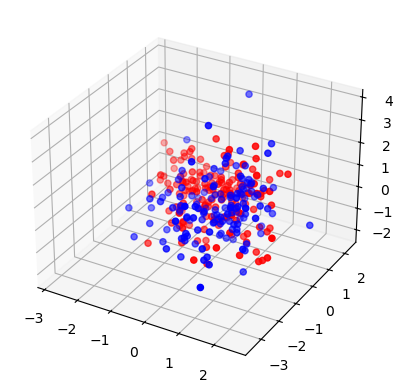

In [33]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[y==1][:,0], x[y==1][:,1], x[y==1][:,2], color='blue')
ax.scatter(x[y==0][:,0], x[y==0][:,1], x[y==0][:,2], color='red')

In [40]:
x = aug_x[:,0:3]
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

In [41]:
data = np.c_[x,y]
np.random.shuffle(data)

a = int(0.75*len(data))
x_train = data[:a,0:3]
x_test = data[a:,0:3]
y_train = data[:a,3]
y_test = data[a:,3]

In [55]:
x_mean = x_train[:,1:].mean()
x_std = x_train[:,1:].std()

x_train[:,1:] = (x_train[:,1:]-x_mean)/x_std
x_test[:,1:] = (x_test[:,1:]-x_mean)/x_std

In [56]:
w = np.zeros(x.shape[1])
lr = 0.01
train_errors = []
n = len(y_train)

for i in range(5000):
    y_pred = sigmoid(x_train@w)
    loss = -(1/n)*np.mean((y_train*np.log(y_pred + 1e-9) + (1-y_train)*np.log(1-y_pred + 1e-9)))
    train_errors.append(loss)

    gradient = (1/n)*(x_train.T @ (y_train - y_pred))
    w += lr*gradient

In [57]:
y_pred = np.sign(x_test @ w)
test_error = np.mean(y_pred != y_test)
test_error

np.float64(0.7631578947368421)

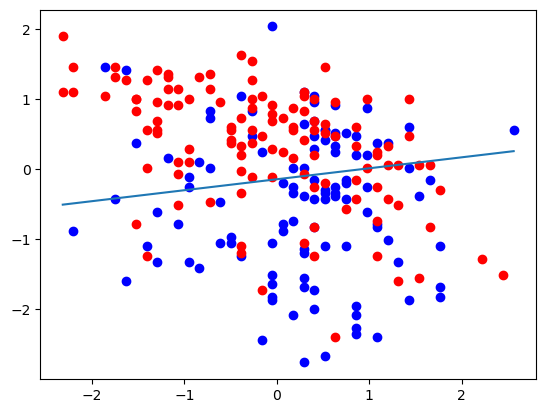

In [58]:
plt.scatter(x_train[y_train==1][:,1], x_train[y_train==1][:,2], color='blue')
plt.scatter(x_train[y_train==0][:,1], x_train[y_train==0][:,2], color='red')

x_line = np.linspace(x_train[:,1].min(), x_train[:,1].max(), 100)
y_line = -(w[0] + w[1]*x_line)/w[2]

plt.plot(x_line, y_line)

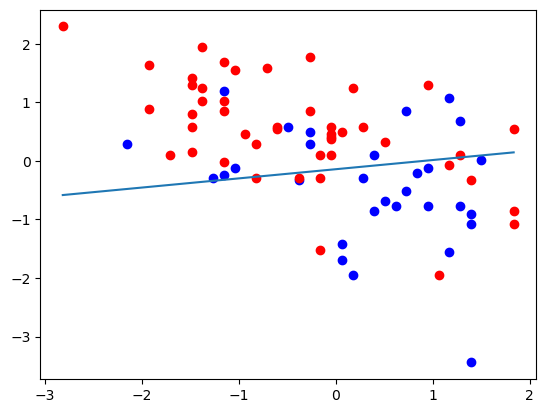

In [59]:
plt.scatter(x_test[y_test==1][:,1], x_test[y_test==1][:,2], color='blue')
plt.scatter(x_test[y_test==0][:,1], x_test[y_test==0][:,2], color='red')

x_line = np.linspace(x_test[:,1].min(), x_test[:,1].max(), 100)
y_line = -(w[0] + w[1]*x_line)/w[2]

plt.plot(x_line, y_line)